In [1]:
!pip install -q transformers datasets accelerate evaluate scikit-learn emoji==0.6.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.3 MB/s eta 0:00:00


In [2]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import gc
import torch
import torch.nn as nn
import pandas as pd
import numpy as np

from datasets import Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.utils.class_weight import compute_class_weight

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [3]:
print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

True
Tesla T4


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
BASE_PATH = "/content/drive/MyDrive/ABSA_BERT_MULTIDOMAIN"

os.makedirs(f"{BASE_PATH}/predictions", exist_ok=True)
os.makedirs(f"{BASE_PATH}/results", exist_ok=True)
os.makedirs(f"{BASE_PATH}/models", exist_ok=True)
os.makedirs(f"{BASE_PATH}/training_history", exist_ok=True)

print("Folders Created")

Folders Created


In [8]:
course_df = pd.read_csv(
    f"{BASE_PATH}/course_balanced.csv"
)

teacher_df = pd.read_csv(
    f"{BASE_PATH}/teacher_balanced.csv"
)

university_df = pd.read_csv(
    f"{BASE_PATH}/university_balanced.csv"
)

course_test = pd.read_csv(
    f"{BASE_PATH}/course_test.csv"
)

teacher_test = pd.read_csv(
    f"{BASE_PATH}/teacher_test.csv"
)

university_test = pd.read_csv(
    f"{BASE_PATH}/university_test.csv"
)

print(course_df.shape)
print(teacher_df.shape)
print(university_df.shape)

(4218, 4)
(4218, 4)
(4218, 4)


In [9]:
train_df = pd.concat([
    course_df,
    teacher_df,
    university_df
]).reset_index(drop=True)

print(train_df.shape)
train_df.head()

(12654, 4)


,review,aspect,sentiment,domain
0,"This course was amazing. For the first time, t...",course,positive,course
1,"This course was amazing. For the first time, t...",lab partner,positive,course
2,"Extremely boring and lectures were useless, bu...",lectures,negative,course
3,"Extremely boring and lectures were useless, bu...",information taught,positive,course
4,"Cool course content, requires effort to get it...",course content,positive,course


In [10]:
def format_input(row):
    return (
        "[DOMAIN] " + str(row["domain"]) +
        " [ASPECT] " + str(row["aspect"]) +
        " [TEXT] " + str(row["review"])
    )

train_df["input_text"] = train_df.apply(
    format_input,
    axis=1
)

course_test["input_text"] = course_test.apply(
    format_input,
    axis=1
)

teacher_test["input_text"] = teacher_test.apply(
    format_input,
    axis=1
)

university_test["input_text"] = university_test.apply(
    format_input,
    axis=1
)

In [11]:
label_map = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

reverse_label_map = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

train_df["label"] = train_df["sentiment"].map(label_map)

course_test["label"] = course_test["sentiment"].map(label_map)
teacher_test["label"] = teacher_test["sentiment"].map(label_map)
university_test["label"] = university_test["sentiment"].map(label_map)

In [12]:
train_df, val_df = train_test_split(
    train_df,
    test_size=0.1,
    stratify=train_df["label"],
    random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(train_df.shape)
print(val_df.shape)

(11388, 6)
(1266, 6)


In [13]:
MODEL_NAME = "vinai/bertweet-base"

In [14]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    normalization=True
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [15]:
train_dataset = Dataset.from_pandas(
    train_df[["input_text", "label"]]
)

val_dataset = Dataset.from_pandas(
    val_df[["input_text", "label"]]
)

course_test_dataset = Dataset.from_pandas(
    course_test[["input_text", "label"]]
)

teacher_test_dataset = Dataset.from_pandas(
    teacher_test[["input_text", "label"]]
)

university_test_dataset = Dataset.from_pandas(
    university_test[["input_text", "label"]]
)

print("Train Dataset:", len(train_dataset))
print("Validation Dataset:", len(val_dataset))
print("Course Test Dataset:", len(course_test_dataset))
print("Teacher Test Dataset:", len(teacher_test_dataset))
print("University Test Dataset:", len(university_test_dataset))

Train Dataset: 11388
Validation Dataset: 1266
Course Test Dataset: 844
Teacher Test Dataset: 844
University Test Dataset: 844


In [16]:
MAX_LEN = 128

def tokenize_function(examples):

    return tokenizer(
        examples["input_text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN
    )

train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

val_dataset = val_dataset.map(
    tokenize_function,
    batched=True
)

course_test_dataset = course_test_dataset.map(
    tokenize_function,
    batched=True
)

teacher_test_dataset = teacher_test_dataset.map(
    tokenize_function,
    batched=True
)

university_test_dataset = university_test_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/11388 [00:00<?, ? examples/s]

Map:   0%|          | 0/1266 [00:00<?, ? examples/s]

Map:   0%|          | 0/844 [00:00<?, ? examples/s]

Map:   0%|          | 0/844 [00:00<?, ? examples/s]

Map:   0%|          | 0/844 [00:00<?, ? examples/s]

In [17]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    preds = np.argmax(logits, axis=1)

    return {

        "accuracy": accuracy_score(
            labels,
            preds
        ),

        "f1_macro": f1_score(
            labels,
            preds,
            average="macro"
        ),

        "f1_weighted": f1_score(
            labels,
            preds,
            average="weighted"
        )
    }

In [18]:
labels = train_df["label"].values

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float
)

print("Class Weights:")
print(class_weights)

Class Weights:
[1.18810642 3.14759536 0.54329469]


In [19]:
class WeightedTrainer(Trainer):

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        **kwargs
    ):

        labels = inputs.get("labels")

        outputs = model(**inputs)

        logits = outputs.get("logits")

        loss_fct = nn.CrossEntropyLoss(
            weight=class_weights_tensor.to(model.device)
        )

        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [20]:
def run_experiment(
    experiment_name,
    learning_rate=2e-5,
    epochs=5,
    batch_size=16
):

    print(f"\nRunning Experiment: {experiment_name}")

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=3
    )

    training_args = TrainingArguments(

        output_dir=f"./{experiment_name}",

        eval_strategy="epoch",

        save_strategy="no",

        learning_rate=learning_rate,

        per_device_train_batch_size=batch_size,

        per_device_eval_batch_size=batch_size,

        num_train_epochs=epochs,

        weight_decay=0.01,

        logging_steps=100,

        fp16=True,

        report_to="none"
    )

    trainer = WeightedTrainer(

        model=model,

        args=training_args,

        train_dataset=train_dataset,

        eval_dataset=val_dataset,

        compute_metrics=compute_metrics
    )

    trainer.train()

    trainer.save_model(
        f"{BASE_PATH}/models/{experiment_name}"
    )

    tokenizer.save_pretrained(
        f"{BASE_PATH}/models/{experiment_name}"
    )

    history = trainer.state.log_history

    history_df = pd.DataFrame(history)

    history_df.to_csv(
        f"{BASE_PATH}/training_history/{experiment_name}_history.csv",
        index=False
    )

    print("\nTraining Completed")

    return trainer

In [21]:
trainer_baseline = run_experiment(
    experiment_name="bertweet_multidomain_baseline",
    learning_rate=2e-5,
    epochs=5,
    batch_size=16
)


Running Experiment: bertweet_multidomain_baseline


pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.597616,0.555121,0.823065,0.736159,0.837204
2,0.450850,0.485759,0.856240,0.781386,0.863018
3,0.340329,0.559497,0.868088,0.789198,0.873829
4,0.267769,0.664259,0.879147,0.802629,0.881769
5,0.207998,0.768677,0.877567,0.795948,0.879123


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training Completed


In [22]:
trainer_lr3e5 = run_experiment(
    experiment_name="bertweet_multidomain_lr3e5",
    learning_rate=3e-5,
    epochs=5,
    batch_size=16
)


Running Experiment: bertweet_multidomain_lr3e5


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.604376,0.572951,0.827014,0.730583,0.836161
2,0.435543,0.490863,0.848341,0.769641,0.857289
3,0.317950,0.538597,0.873618,0.796816,0.878705
4,0.253941,0.673350,0.868088,0.795183,0.874536
5,0.146464,0.828695,0.870458,0.784733,0.871708


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training Completed


In [23]:
trainer_lr1e5 = run_experiment(
    experiment_name="bertweet_multidomain_lr1e5",
    learning_rate=1e-5,
    epochs=5,
    batch_size=16
)


Running Experiment: bertweet_multidomain_lr1e5


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.613317,0.575541,0.815166,0.722510,0.829699
2,0.471385,0.552463,0.847551,0.761114,0.854871
3,0.414020,0.534146,0.853081,0.772277,0.860726
4,0.362439,0.588126,0.854660,0.773954,0.861644
5,0.303087,0.639634,0.867299,0.784392,0.869966


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training Completed


In [24]:
trainer_batch32 = run_experiment(
    experiment_name="bertweet_multidomain_batch32",
    learning_rate=2e-5,
    epochs=5,
    batch_size=32
)


Running Experiment: bertweet_multidomain_batch32


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.600167,0.558796,0.830964,0.743898,0.841629
2,0.469931,0.503902,0.842022,0.761771,0.852492
3,0.357865,0.483929,0.846761,0.772653,0.860211
4,0.264468,0.546717,0.872038,0.798973,0.878397
5,0.220004,0.612790,0.879147,0.801037,0.881994


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training Completed


In [25]:
trainer_batch8 = run_experiment(
    experiment_name="bertweet_multidomain_batch8",
    learning_rate=2e-5,
    epochs=5,
    batch_size=8
)


Running Experiment: bertweet_multidomain_batch8


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.652114,0.567251,0.843602,0.758371,0.849732
2,0.562001,0.623773,0.863349,0.770103,0.865744
3,0.451156,0.628949,0.879937,0.803579,0.883342
4,0.236709,0.796392,0.880727,0.801802,0.882451
5,0.129239,0.882433,0.882306,0.803419,0.883750


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training Completed


In [26]:
trainer_epoch3 = run_experiment(
    experiment_name="bertweet_multidomain_epoch3",
    learning_rate=2e-5,
    epochs=3,
    batch_size=8
)


Running Experiment: bertweet_multidomain_epoch3


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.679779,0.569958,0.840442,0.743949,0.845869
2,0.546916,0.651202,0.869668,0.775167,0.868710
3,0.288158,0.712335,0.886256,0.807598,0.885685


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training Completed


In [27]:
trainer_epoch7 = run_experiment(
    experiment_name="bertweet_multidomain_epoch7",
    learning_rate=2e-5,
    epochs=7,
    batch_size=8
)


Running Experiment: bertweet_multidomain_epoch7


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.702153,0.538503,0.835703,0.745463,0.844189
2,0.574539,0.523143,0.854660,0.781363,0.863696
3,0.394301,0.659488,0.861769,0.780633,0.867483
4,0.282310,0.816935,0.879147,0.794740,0.879231
5,0.172765,0.970556,0.877567,0.796647,0.879986
6,0.255618,0.963704,0.879937,0.804327,0.881546
7,0.085189,1.004318,0.889415,0.815010,0.889832


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training Completed


In [28]:
def evaluate_domain(
    trainer,
    test_dataset,
    test_df,
    domain_name,
    experiment_name
):

    print(f"\nEvaluating {domain_name}")

    # =====================================================
    # EVALUATION
    # =====================================================

    results = trainer.evaluate(test_dataset)

    predictions = trainer.predict(test_dataset)

    y_pred = np.argmax(
        predictions.predictions,
        axis=1
    )

    y_true = predictions.label_ids

    # =====================================================
    # CLASSIFICATION REPORT
    # =====================================================

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=[
            "negative",
            "neutral",
            "positive"
        ],
        output_dict=True
    )

    report_df = pd.DataFrame(report_dict).transpose()

    report_df.to_csv(
        f"{BASE_PATH}/results/{experiment_name}_{domain_name}_classification_report.csv"
    )

    print(report_df)

    # =====================================================
    # CONFUSION MATRIX
    # =====================================================

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    cm_df = pd.DataFrame(
        cm,
        index=[
            "Actual Negative",
            "Actual Neutral",
            "Actual Positive"
        ],
        columns=[
            "Pred Negative",
            "Pred Neutral",
            "Pred Positive"
        ]
    )

    cm_df.to_csv(
        f"{BASE_PATH}/results/{experiment_name}_{domain_name}_confusion_matrix.csv"
    )

    print(cm_df)

    # =====================================================
    # FINAL PREDICTIONS
    # =====================================================

    final_predictions_df = test_df.copy()

    final_predictions_df["true_label"] = y_true

    final_predictions_df["predicted_label"] = y_pred

    final_predictions_df["true_sentiment"] = (
        final_predictions_df["true_label"]
        .map(reverse_label_map)
    )

    final_predictions_df["predicted_sentiment"] = (
        final_predictions_df["predicted_label"]
        .map(reverse_label_map)
    )

    final_predictions_df.to_csv(
        f"{BASE_PATH}/predictions/{experiment_name}_{domain_name}_predictions.csv",
        index=False
    )

    print(final_predictions_df.head())

    # =====================================================
    # ERROR ANALYSIS
    # =====================================================

    errors_df = final_predictions_df[
        final_predictions_df["true_label"]
        != final_predictions_df["predicted_label"]
    ]

    errors_df.to_csv(
        f"{BASE_PATH}/results/{experiment_name}_{domain_name}_errors.csv",
        index=False
    )

    print("Total Errors:", len(errors_df))

    # =====================================================
    # NEUTRAL ERRORS
    # =====================================================

    neutral_errors = errors_df[
        errors_df["true_sentiment"] == "neutral"
    ]

    neutral_errors.to_csv(
        f"{BASE_PATH}/results/{experiment_name}_{domain_name}_neutral_errors.csv",
        index=False
    )

    print("Neutral Errors:", len(neutral_errors))

    # =====================================================
    # METRICS CSV
    # =====================================================

    metrics_df = pd.DataFrame({

        "Metric": [
            "Accuracy",
            "Macro_F1",
            "Weighted_F1"
        ],

        "Score": [
            results["eval_accuracy"],
            results["eval_f1_macro"],
            results["eval_f1_weighted"]
        ]
    })

    metrics_df.to_csv(
        f"{BASE_PATH}/results/{experiment_name}_{domain_name}_metrics.csv",
        index=False
    )

    print(metrics_df)

    return metrics_df

In [29]:
course_metrics = evaluate_domain(
    trainer=trainer_epoch7,
    test_dataset=course_test_dataset,
    test_df=course_test,
    domain_name="course",
    experiment_name="bertweet_multidomain_best"
)


Evaluating course


              precision    recall  f1-score     support
negative       0.957143  0.920962  0.938704  291.000000
neutral        0.883117  0.937931  0.909699  145.000000
positive       0.960976  0.965686  0.963325  408.000000
accuracy       0.945498  0.945498  0.945498    0.945498
macro avg      0.933745  0.941527  0.937243  844.000000
weighted avg   0.946278  0.945498  0.945623  844.000000
                 Pred Negative  Pred Neutral  Pred Positive
Actual Negative            268            13             10
Actual Neutral               3           136              6
Actual Positive              9             5            394
                                              review                 aspect  \
0  The programming language( Scheme/ Dr. Racket) ...   programming language   
1  This class is literally just epsilon and delta...         mobius quizzes   
2  Overall content heavy and quite a tricky cours...                 course   
3  Professor Sneed's class was a semi tough one. ...

In [30]:
teacher_metrics = evaluate_domain(
    trainer=trainer_epoch7,
    test_dataset=teacher_test_dataset,
    test_df=teacher_test,
    domain_name="teacher",
    experiment_name="bertweet_multidomain_best"
)


Evaluating teacher


              precision    recall  f1-score   support
negative       0.965035  0.958333  0.961672  288.0000
neutral        0.903614  0.862069  0.882353   87.0000
positive       0.968421  0.980810  0.974576  469.0000
accuracy       0.960900  0.960900  0.960900    0.9609
macro avg      0.945690  0.933738  0.939534  844.0000
weighted avg   0.960585  0.960900  0.960667  844.0000
                 Pred Negative  Pred Neutral  Pred Positive
Actual Negative            276             4              8
Actual Neutral               5            75              7
Actual Positive              5             4            460
                                              review                  aspect  \
0  This class was harder than I expected, especia...              This class   
1  Good teacher, very helpful. He is very funny a...                 teacher   
2  Ms. Young is a great professor. I was computer...              this class   
3  TURN YOUR WORK IN ON TIME!!!! In only the seco...          

In [31]:
university_metrics = evaluate_domain(
    trainer=trainer_epoch7,
    test_dataset=university_test_dataset,
    test_df=university_test,
    domain_name="university",
    experiment_name="bertweet_multidomain_best"
)


Evaluating university


              precision    recall  f1-score     support
negative       0.992481  1.000000  0.996226  132.000000
neutral        1.000000  0.916667  0.956522   36.000000
positive       0.997050  1.000000  0.998523  676.000000
accuracy       0.996445  0.996445  0.996445    0.996445
macro avg      0.996510  0.972222  0.983757  844.000000
weighted avg   0.996461  0.996445  0.996372  844.000000
                 Pred Negative  Pred Neutral  Pred Positive
Actual Negative            132             0              0
Actual Neutral               1            33              2
Actual Positive              0             0            676
                                              review                 aspect  \
0  Exeter University was my first choice and I do...              community   
1  Nice university to study in, all the teachers ...             university   
2  I love the options for my course and the uni i...  options for my course   
3  It’s difficult for me to rate the aspects of t...

In [32]:
import pandas as pd
import os

history_path = f"{BASE_PATH}/training_history"

experiment_files = {

    "Baseline_BS16_E5_LR2e5":
        "bertweet_multidomain_baseline_history.csv",

    "LR3e5":
        "bertweet_multidomain_lr3e5_history.csv",

    "LR1e5":
        "bertweet_multidomain_lr1e5_history.csv",

    "Batch32":
        "bertweet_multidomain_batch32_history.csv",

    "Batch8":
        "bertweet_multidomain_batch8_history.csv",

    "Batch8_Epoch3":
        "bertweet_multidomain_epoch3_history.csv",

    "Batch8_Epoch7_FINAL":
        "bertweet_multidomain_epoch7_history.csv"
}

summary_rows = []

for experiment_name, filename in experiment_files.items():

    file_path = os.path.join(
        history_path,
        filename
    )

    history_df = pd.read_csv(file_path)

    eval_rows = history_df[
        history_df["eval_accuracy"].notna()
    ]

    best_row = eval_rows.loc[
        eval_rows["eval_f1_weighted"].idxmax()
    ]

    summary_rows.append({

        "Configuration": experiment_name,

        "Best_Epoch": best_row["epoch"],

        "Accuracy": best_row["eval_accuracy"],

        "Macro_F1": best_row["eval_f1_macro"],

        "Weighted_F1": best_row["eval_f1_weighted"],

        "Validation_Loss": best_row["eval_loss"]
    })

final_results = pd.DataFrame(summary_rows)

final_results = final_results.sort_values(
    by="Weighted_F1",
    ascending=False
)

print(final_results)

final_results.to_csv(
    f"{BASE_PATH}/results/final_hypertuning_summary.csv",
    index=False
)

            Configuration  Best_Epoch  Accuracy  Macro_F1  Weighted_F1  \
6     Batch8_Epoch7_FINAL         7.0  0.889415  0.815010     0.889832   
5           Batch8_Epoch3         3.0  0.886256  0.807598     0.885685   
4                  Batch8         5.0  0.882306  0.803419     0.883750   
3                 Batch32         5.0  0.879147  0.801037     0.881994   
0  Baseline_BS16_E5_LR2e5         4.0  0.879147  0.802629     0.881769   
1                   LR3e5         3.0  0.873618  0.796816     0.878705   
2                   LR1e5         5.0  0.867299  0.784392     0.869966   

   Validation_Loss  
6         1.004318  
5         0.712335  
4         0.882433  
3         0.612790  
0         0.664259  
1         0.538597  
2         0.639634  


In [35]:
cross_course = pd.read_csv(
    f"{BASE_PATH}/course_teacher_to_university_lr3e5_predictions.csv"
)

cross_teacher = pd.read_csv(
    f"{BASE_PATH}/course_university_to_teacher_lr3e5_predictions.csv"
)

cross_university = pd.read_csv(
    f"{BASE_PATH}/university_teacher_to_course_lr3e5_predictions.csv"
)

print(cross_course.shape)
print(cross_teacher.shape)
print(cross_university.shape)

(844, 11)
(844, 11)
(844, 11)


In [36]:
multi_course = pd.read_csv(
    f"{BASE_PATH}/predictions/bertweet_multidomain_best_course_predictions.csv"
)

multi_teacher = pd.read_csv(
    f"{BASE_PATH}/predictions/bertweet_multidomain_best_teacher_predictions.csv"
)

multi_university = pd.read_csv(
    f"{BASE_PATH}/predictions/bertweet_multidomain_best_university_predictions.csv"
)

print(multi_course.shape)
print(multi_teacher.shape)
print(multi_university.shape)

(844, 11)
(844, 11)
(844, 11)


In [38]:
course_compare = multi_course.merge(

    cross_university[[
        "row_id",
        "predicted_sentiment"
    ]],

    on="row_id",

    suffixes=(
        "_multidomain",
        "_crossdomain"
    )
)

course_compare["multi_correct"] = (
    course_compare["true_sentiment"]
    ==
    course_compare["predicted_sentiment_multidomain"]
)

course_compare["cross_correct"] = (
    course_compare["true_sentiment"]
    ==
    course_compare["predicted_sentiment_crossdomain"]
)

course_compare["disagreement"] = (
    course_compare["predicted_sentiment_multidomain"]
    !=
    course_compare["predicted_sentiment_crossdomain"]
)

print(course_compare.head())

print("\nTotal Samples:", len(course_compare))

print(
    "\nDisagreements:",
    course_compare["disagreement"].sum()
)

print(
    "\nBoth Correct:",
    len(course_compare[
        (course_compare["multi_correct"] == True)
        &
        (course_compare["cross_correct"] == True)
    ])
)

print(
    "\nOnly Multidomain Correct:",
    len(course_compare[
        (course_compare["multi_correct"] == True)
        &
        (course_compare["cross_correct"] == False)
    ])
)

print(
    "\nOnly Cross-domain Correct:",
    len(course_compare[
        (course_compare["multi_correct"] == False)
        &
        (course_compare["cross_correct"] == True)
    ])
)

print(
    "\nBoth Wrong:",
    len(course_compare[
        (course_compare["multi_correct"] == False)
        &
        (course_compare["cross_correct"] == False)
    ])
)

                                              review                 aspect  \
0  The programming language( Scheme/ Dr. Racket) ...   programming language   
1  This class is literally just epsilon and delta...         mobius quizzes   
2  Overall content heavy and quite a tricky cours...                 course   
3  Professor Sneed's class was a semi tough one. ...  Professor Sneed class   
4  Despite many ppl complaining about the Mobius ...                 desmos   

  sentiment  domain       row_id  \
0  negative  course   course_188   
1  negative  course  course_3409   
2  negative  course   course_254   
3  positive  course  course_1797   
4  positive  course  course_3891   

                                          input_text  label  true_label  \
0  [DOMAIN] course [ASPECT] programming language ...      0           0   
1  [DOMAIN] course [ASPECT] mobius quizzes [TEXT]...      0           0   
2  [DOMAIN] course [ASPECT] course [TEXT] Overall...      0           0   
3  [DOMA

In [39]:
course_disagreements = course_compare[
    course_compare["disagreement"] == True
]

course_disagreements.to_csv(
    f"{BASE_PATH}/results/course_multidomain_vs_crossdomain_disagreements.csv",
    index=False
)

print(course_disagreements.shape)

course_disagreements.head()

(173, 15)


,review,aspect,sentiment,domain,row_id,input_text,label,true_label,predicted_label,true_sentiment,predicted_sentiment_multidomain,predicted_sentiment_crossdomain,multi_correct,cross_correct,disagreement
0,The programming language( Scheme/ Dr. Racket) ...,programming language,negative,course,course_188,[DOMAIN] course [ASPECT] programming language ...,0,0,1,negative,neutral,negative,False,True,True
5,First half of the course was easy. Second half...,Second half,negative,course,course_1129,[DOMAIN] course [ASPECT] Second half [TEXT] Fi...,0,0,0,negative,negative,positive,True,False,True
12,Theory-based statistics course that is actuall...,taking this course,neutral,course,course_4086,[DOMAIN] course [ASPECT] taking this course [T...,1,1,1,neutral,neutral,negative,True,False,True
18,Very straightforward course- the courseware pr...,amount of information,negative,course,course_578,[DOMAIN] course [ASPECT] amount of information...,0,0,0,negative,negative,neutral,True,False,True
24,Standard PD course.,PD course,neutral,course,course_1943,[DOMAIN] course [ASPECT] PD course [TEXT] Stan...,1,1,1,neutral,neutral,positive,True,False,True


In [40]:
teacher_compare = multi_teacher.merge(

    cross_teacher[[
        "row_id",
        "predicted_sentiment"
    ]],

    on="row_id",

    suffixes=(
        "_multidomain",
        "_crossdomain"
    )
)

teacher_compare["multi_correct"] = (
    teacher_compare["true_sentiment"]
    ==
    teacher_compare["predicted_sentiment_multidomain"]
)

teacher_compare["cross_correct"] = (
    teacher_compare["true_sentiment"]
    ==
    teacher_compare["predicted_sentiment_crossdomain"]
)

teacher_compare["disagreement"] = (
    teacher_compare["predicted_sentiment_multidomain"]
    !=
    teacher_compare["predicted_sentiment_crossdomain"]
)

print("\nTotal Samples:", len(teacher_compare))

print(
    "\nDisagreements:",
    teacher_compare["disagreement"].sum()
)

print(
    "\nBoth Correct:",
    len(teacher_compare[
        (teacher_compare["multi_correct"] == True)
        &
        (teacher_compare["cross_correct"] == True)
    ])
)

print(
    "\nOnly Multidomain Correct:",
    len(teacher_compare[
        (teacher_compare["multi_correct"] == True)
        &
        (teacher_compare["cross_correct"] == False)
    ])
)

print(
    "\nOnly Cross-domain Correct:",
    len(teacher_compare[
        (teacher_compare["multi_correct"] == False)
        &
        (teacher_compare["cross_correct"] == True)
    ])
)

print(
    "\nBoth Wrong:",
    len(teacher_compare[
        (teacher_compare["multi_correct"] == False)
        &
        (teacher_compare["cross_correct"] == False)
    ])
)


Total Samples: 844

Disagreements: 116

Both Correct: 709

Only Multidomain Correct: 102

Only Cross-domain Correct: 4

Both Wrong: 29


In [41]:
teacher_disagreements = teacher_compare[
    teacher_compare["disagreement"] == True
]

teacher_disagreements.to_csv(
    f"{BASE_PATH}/results/teacher_multidomain_vs_crossdomain_disagreements.csv",
    index=False
)

print(teacher_disagreements.shape)

teacher_disagreements.head()

(116, 15)


,review,aspect,sentiment,domain,row_id,input_text,label,true_label,predicted_label,true_sentiment,predicted_sentiment_multidomain,predicted_sentiment_crossdomain,multi_correct,cross_correct,disagreement
11,"Just like a typical analog course, started fro...",Prof. Levine,positive,teacher,teacher_190,[DOMAIN] teacher [ASPECT] Prof. Levine [TEXT] ...,2,2,2,positive,positive,neutral,True,False,True
15,Very helpful... sometimes a lot of work but ve...,work,neutral,teacher,teacher_1804,[DOMAIN] teacher [ASPECT] work [TEXT] Very hel...,1,1,1,neutral,neutral,negative,True,False,True
16,Kaelin is really relaxed. He's very funny and ...,homework,positive,teacher,teacher_265,[DOMAIN] teacher [ASPECT] homework [TEXT] Kael...,2,2,2,positive,positive,neutral,True,False,True
20,Crystal clear in syllabus / calendar. Weekly d...,points possible,positive,teacher,teacher_3080,[DOMAIN] teacher [ASPECT] points possible [TEX...,2,2,2,positive,positive,neutral,True,False,True
56,Really easy class! I definitely recommend it! ...,assignments,neutral,teacher,teacher_23,[DOMAIN] teacher [ASPECT] assignments [TEXT] R...,1,1,0,neutral,negative,positive,False,False,True


In [42]:
university_compare = multi_university.merge(

    cross_course[[
        "row_id",
        "predicted_sentiment"
    ]],

    on="row_id",

    suffixes=(
        "_multidomain",
        "_crossdomain"
    )
)

university_compare["multi_correct"] = (
    university_compare["true_sentiment"]
    ==
    university_compare["predicted_sentiment_multidomain"]
)

university_compare["cross_correct"] = (
    university_compare["true_sentiment"]
    ==
    university_compare["predicted_sentiment_crossdomain"]
)

university_compare["disagreement"] = (
    university_compare["predicted_sentiment_multidomain"]
    !=
    university_compare["predicted_sentiment_crossdomain"]
)

print("\nTotal Samples:", len(university_compare))

print(
    "\nDisagreements:",
    university_compare["disagreement"].sum()
)

print(
    "\nBoth Correct:",
    len(university_compare[
        (university_compare["multi_correct"] == True)
        &
        (university_compare["cross_correct"] == True)
    ])
)

print(
    "\nOnly Multidomain Correct:",
    len(university_compare[
        (course_compare["multi_correct"] == True)
        &
        (university_compare["cross_correct"] == False)
    ])
)

print(
    "\nOnly Cross-domain Correct:",
    len(university_compare[
        (university_compare["multi_correct"] == False)
        &
        (university_compare["cross_correct"] == True)
    ])
)

print(
    "\nBoth Wrong:",
    len(university_compare[
        (university_compare["multi_correct"] == False)
        &
        (university_compare["cross_correct"] == False)
    ])
)


Total Samples: 844

Disagreements: 67

Both Correct: 777

Only Multidomain Correct: 62

Only Cross-domain Correct: 0

Both Wrong: 3


In [43]:
comparison_summary = pd.DataFrame({

    "Domain": [
        "Course",
        "Teacher",
        "University"
    ],

    "Total_Samples": [
        len(course_compare),
        len(teacher_compare),
        len(university_compare)
    ],

    "Disagreements": [
        course_compare["disagreement"].sum(),
        teacher_compare["disagreement"].sum(),
        university_compare["disagreement"].sum()
    ],

    "Both_Correct": [

        len(course_compare[
            (course_compare["multi_correct"] == True)
            &
            (course_compare["cross_correct"] == True)
        ]),

        len(teacher_compare[
            (teacher_compare["multi_correct"] == True)
            &
            (teacher_compare["cross_correct"] == True)
        ]),

        len(university_compare[
            (university_compare["multi_correct"] == True)
            &
            (university_compare["cross_correct"] == True)
        ])
    ],

    "Only_Multidomain_Correct": [

        len(course_compare[
            (course_compare["multi_correct"] == True)
            &
            (course_compare["cross_correct"] == False)
        ]),

        len(teacher_compare[
            (teacher_compare["multi_correct"] == True)
            &
            (teacher_compare["cross_correct"] == False)
        ]),

        len(university_compare[
            (university_compare["multi_correct"] == True)
            &
            (university_compare["cross_correct"] == False)
        ])
    ],

    "Only_Crossdomain_Correct": [

        len(course_compare[
            (course_compare["multi_correct"] == False)
            &
            (course_compare["cross_correct"] == True)
        ]),

        len(teacher_compare[
            (teacher_compare["multi_correct"] == False)
            &
            (teacher_compare["cross_correct"] == True)
        ]),

        len(university_compare[
            (university_compare["multi_correct"] == False)
            &
            (university_compare["cross_correct"] == True)
        ])
    ],

    "Both_Wrong": [

        len(course_compare[
            (course_compare["multi_correct"] == False)
            &
            (course_compare["cross_correct"] == False)
        ]),

        len(teacher_compare[
            (teacher_compare["multi_correct"] == False)
            &
            (teacher_compare["cross_correct"] == False)
        ]),

        len(university_compare[
            (university_compare["multi_correct"] == False)
            &
            (university_compare["cross_correct"] == False)
        ])
    ]
})

print(comparison_summary)

comparison_summary.to_csv(
    f"{BASE_PATH}/results/final_multidomain_vs_crossdomain_summary.csv",
    index=False
)

       Domain  Total_Samples  Disagreements  Both_Correct  \
0      Course            844            173           642   
1     Teacher            844            116           709   
2  University            844             67           777   

   Only_Multidomain_Correct  Only_Crossdomain_Correct  Both_Wrong  
0                       156                        15          31  
1                       102                         4          29  
2                        64                         0           3  


In [44]:
final_domain_results = pd.DataFrame({

    "Domain": [
        "Course",
        "Teacher",
        "University"
    ],

    "Accuracy": [
        course_metrics.loc[
            course_metrics["Metric"] == "Accuracy",
            "Score"
        ].values[0],

        teacher_metrics.loc[
            teacher_metrics["Metric"] == "Accuracy",
            "Score"
        ].values[0],

        university_metrics.loc[
            university_metrics["Metric"] == "Accuracy",
            "Score"
        ].values[0]
    ],

    "Macro_F1": [

        course_metrics.loc[
            course_metrics["Metric"] == "Macro_F1",
            "Score"
        ].values[0],

        teacher_metrics.loc[
            teacher_metrics["Metric"] == "Macro_F1",
            "Score"
        ].values[0],

        university_metrics.loc[
            university_metrics["Metric"] == "Macro_F1",
            "Score"
        ].values[0]
    ],

    "Weighted_F1": [

        course_metrics.loc[
            course_metrics["Metric"] == "Weighted_F1",
            "Score"
        ].values[0],

        teacher_metrics.loc[
            teacher_metrics["Metric"] == "Weighted_F1",
            "Score"
        ].values[0],

        university_metrics.loc[
            university_metrics["Metric"] == "Weighted_F1",
            "Score"
        ].values[0]
    ]
})

print(final_domain_results)

final_domain_results.to_csv(
    f"{BASE_PATH}/results/final_domain_performance_summary.csv",
    index=False
)

       Domain  Accuracy  Macro_F1  Weighted_F1
0      Course  0.945498  0.937243     0.945623
1     Teacher  0.960900  0.939534     0.960667
2  University  0.996445  0.983757     0.996372


In [45]:
overall_results = pd.DataFrame({

    "Metric": [
        "Mean_Accuracy",
        "Mean_Macro_F1",
        "Mean_Weighted_F1"
    ],

    "Score": [

        final_domain_results["Accuracy"].mean(),

        final_domain_results["Macro_F1"].mean(),

        final_domain_results["Weighted_F1"].mean()
    ]
})

print(overall_results)

overall_results.to_csv(
    f"{BASE_PATH}/results/overall_multidomain_performance.csv",
    index=False
)

             Metric     Score
0     Mean_Accuracy  0.967615
1     Mean_Macro_F1  0.953511
2  Mean_Weighted_F1  0.967554


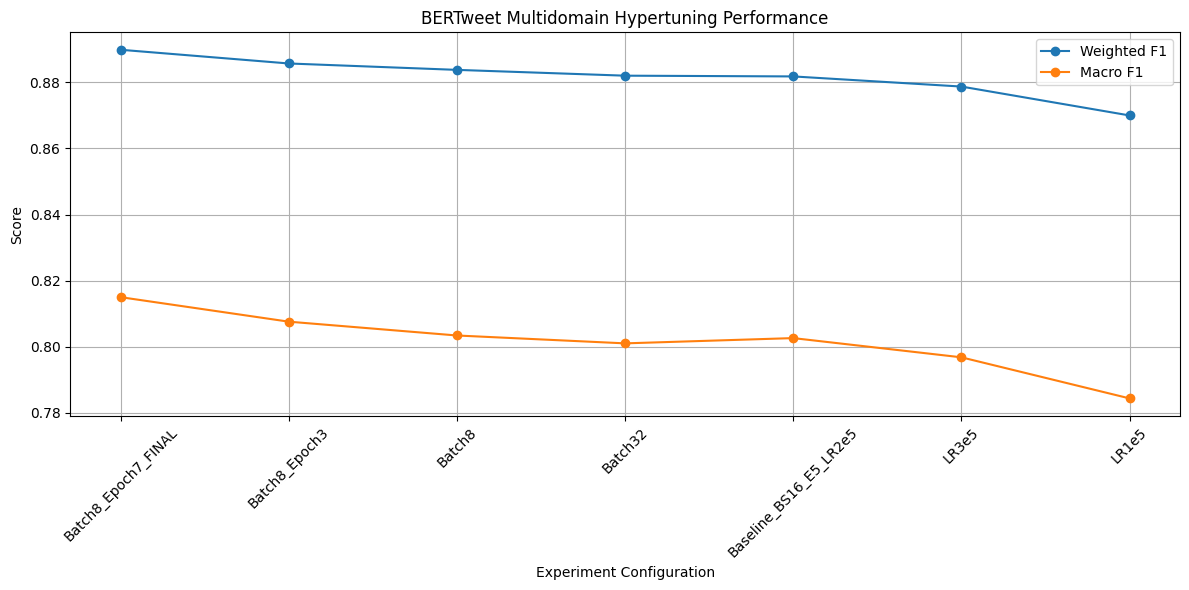

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    final_results["Configuration"],
    final_results["Weighted_F1"],
    marker='o',
    label="Weighted F1"
)

plt.plot(
    final_results["Configuration"],
    final_results["Macro_F1"],
    marker='o',
    label="Macro F1"
)

plt.xticks(rotation=45)

plt.xlabel("Experiment Configuration")

plt.ylabel("Score")

plt.title("BERTweet Multidomain Hypertuning Performance")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    f"{BASE_PATH}/results/bertweet_hypertuning_performance.png"
)

plt.show()

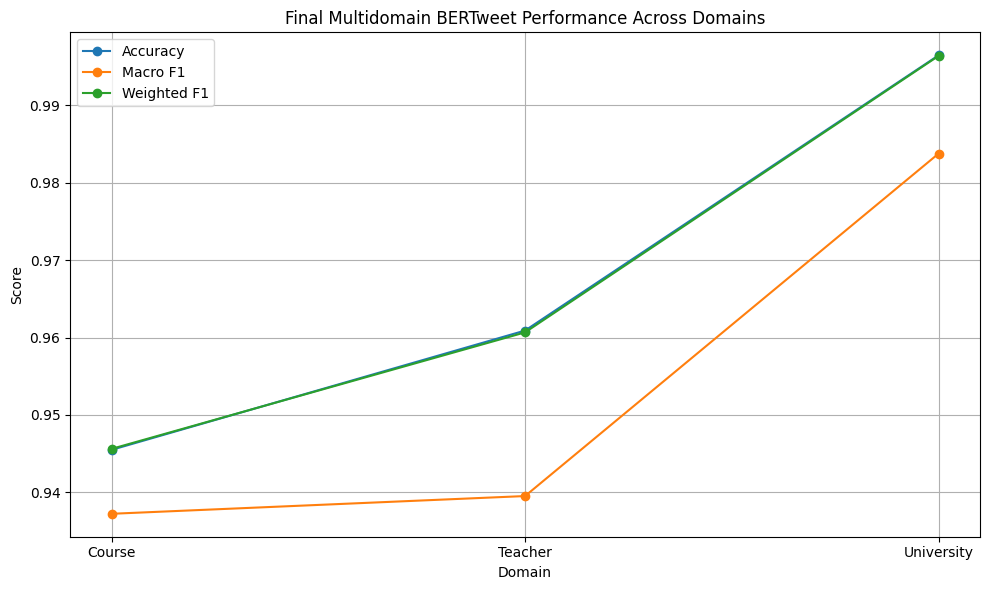

In [47]:
plt.figure(figsize=(10, 6))

plt.plot(
    final_domain_results["Domain"],
    final_domain_results["Accuracy"],
    marker='o',
    label="Accuracy"
)

plt.plot(
    final_domain_results["Domain"],
    final_domain_results["Macro_F1"],
    marker='o',
    label="Macro F1"
)

plt.plot(
    final_domain_results["Domain"],
    final_domain_results["Weighted_F1"],
    marker='o',
    label="Weighted F1"
)

plt.xlabel("Domain")

plt.ylabel("Score")

plt.title("Final Multidomain BERTweet Performance Across Domains")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    f"{BASE_PATH}/results/final_domain_performance_plot.png"
)

plt.show()

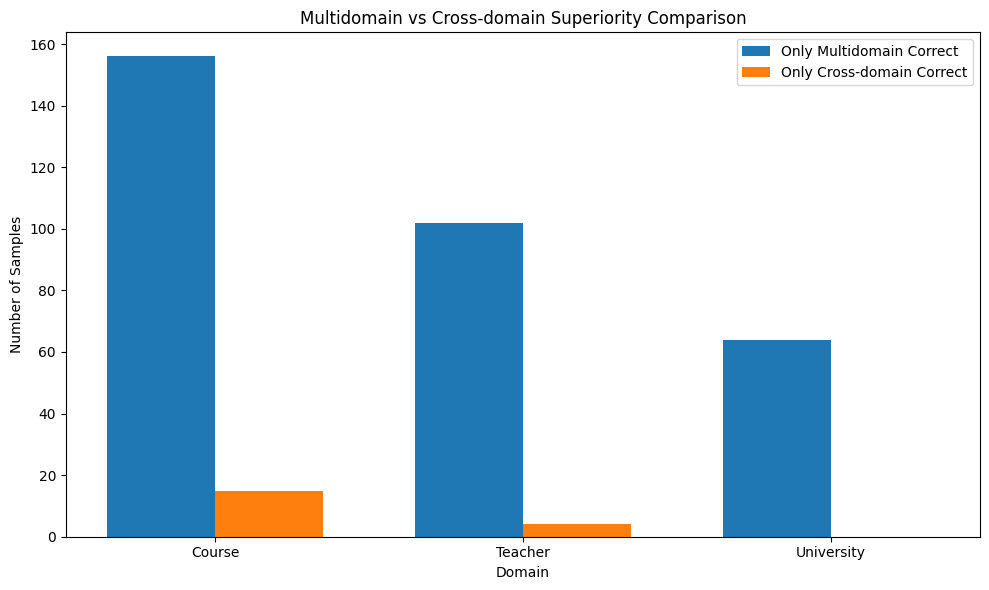

In [48]:
import numpy as np

x = np.arange(len(comparison_summary["Domain"]))

width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    comparison_summary["Only_Multidomain_Correct"],
    width,
    label="Only Multidomain Correct"
)

plt.bar(
    x + width/2,
    comparison_summary["Only_Crossdomain_Correct"],
    width,
    label="Only Cross-domain Correct"
)

plt.xticks(
    x,
    comparison_summary["Domain"]
)

plt.ylabel("Number of Samples")

plt.xlabel("Domain")

plt.title("Multidomain vs Cross-domain Superiority Comparison")

plt.legend()

plt.tight_layout()

plt.savefig(
    f"{BASE_PATH}/results/multidomain_vs_crossdomain_superiority.png"
)

plt.show()

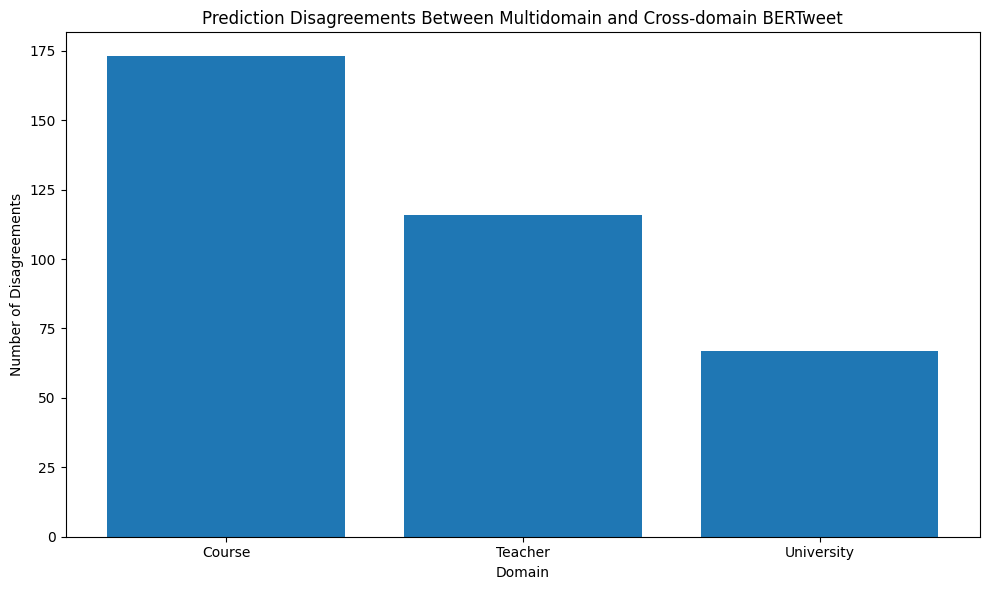

In [49]:
plt.figure(figsize=(10, 6))

plt.bar(
    comparison_summary["Domain"],
    comparison_summary["Disagreements"]
)

plt.xlabel("Domain")

plt.ylabel("Number of Disagreements")

plt.title("Prediction Disagreements Between Multidomain and Cross-domain BERTweet")

plt.tight_layout()

plt.savefig(
    f"{BASE_PATH}/results/disagreement_counts.png"
)

plt.show()

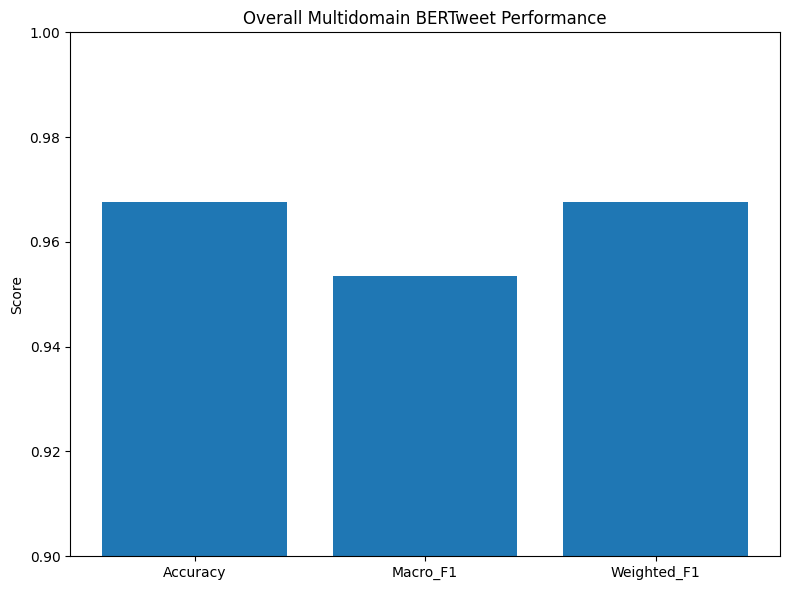

In [50]:
metrics = [
    "Accuracy",
    "Macro_F1",
    "Weighted_F1"
]

scores = [
    overall_results.loc[
        overall_results["Metric"] == "Mean_Accuracy",
        "Score"
    ].values[0],

    overall_results.loc[
        overall_results["Metric"] == "Mean_Macro_F1",
        "Score"
    ].values[0],

    overall_results.loc[
        overall_results["Metric"] == "Mean_Weighted_F1",
        "Score"
    ].values[0]
]

plt.figure(figsize=(8, 6))

plt.bar(
    metrics,
    scores
)

plt.ylim(0.9, 1.0)

plt.ylabel("Score")

plt.title("Overall Multidomain BERTweet Performance")

plt.tight_layout()

plt.savefig(
    f"{BASE_PATH}/results/overall_multidomain_performance_plot.png"
)

plt.show()

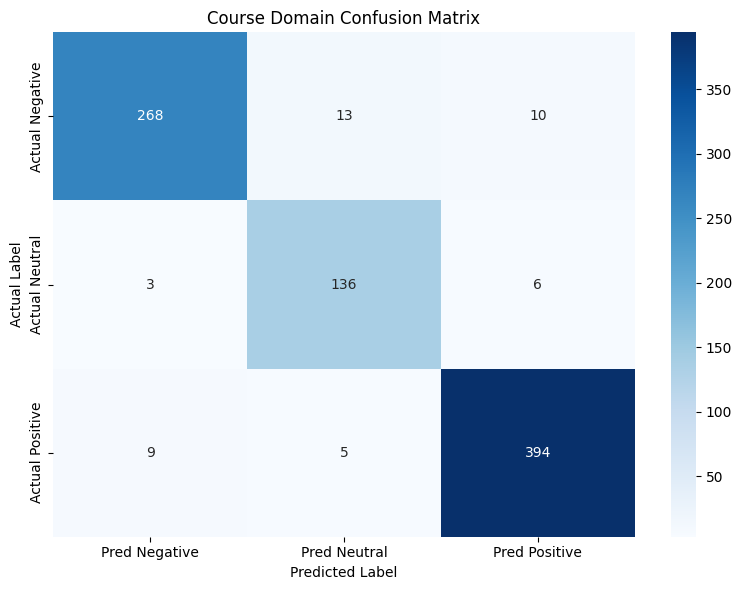

In [51]:
import seaborn as sns

course_cm = pd.read_csv(
    f"{BASE_PATH}/results/bertweet_multidomain_best_course_confusion_matrix.csv",
    index_col=0
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    course_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Course Domain Confusion Matrix")

plt.ylabel("Actual Label")

plt.xlabel("Predicted Label")

plt.tight_layout()

plt.savefig(
    f"{BASE_PATH}/results/course_confusion_matrix_heatmap.png"
)

plt.show()

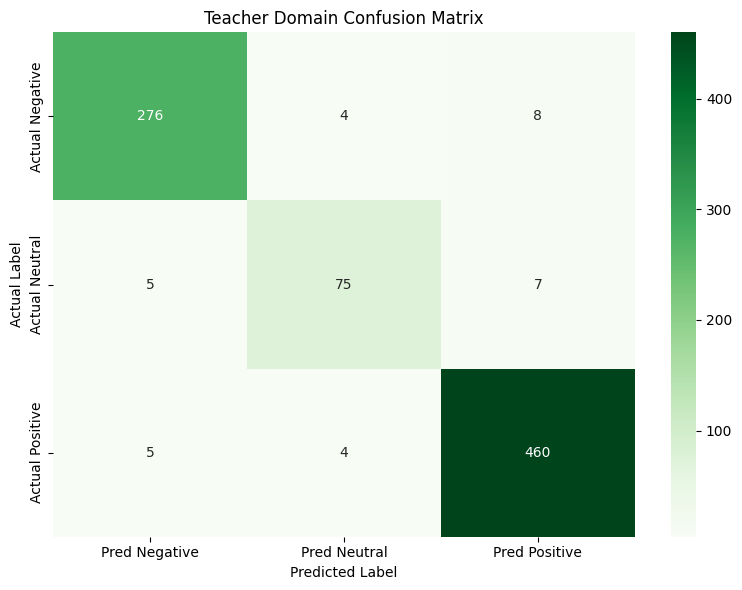

In [52]:
teacher_cm = pd.read_csv(
    f"{BASE_PATH}/results/bertweet_multidomain_best_teacher_confusion_matrix.csv",
    index_col=0
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    teacher_cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Teacher Domain Confusion Matrix")

plt.ylabel("Actual Label")

plt.xlabel("Predicted Label")

plt.tight_layout()

plt.savefig(
    f"{BASE_PATH}/results/teacher_confusion_matrix_heatmap.png"
)

plt.show()

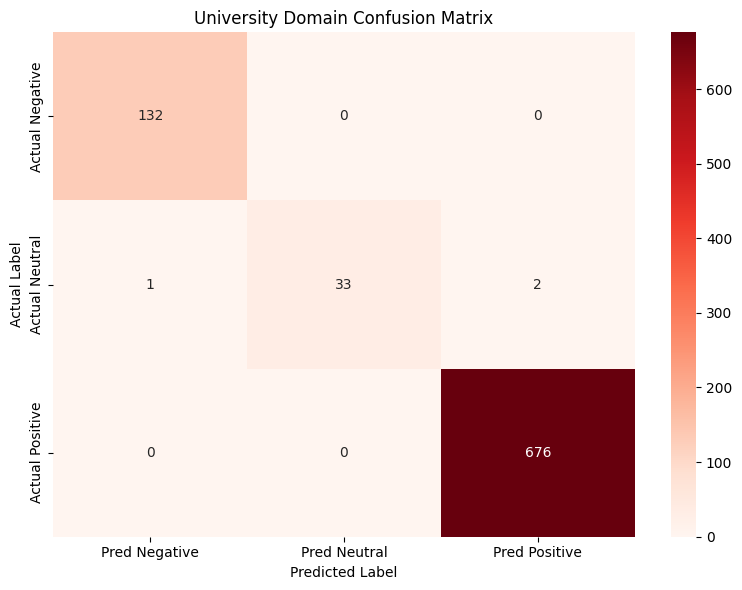

In [53]:
university_cm = pd.read_csv(
    f"{BASE_PATH}/results/bertweet_multidomain_best_university_confusion_matrix.csv",
    index_col=0
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    university_cm,
    annot=True,
    fmt="d",
    cmap="Reds"
)

plt.title("University Domain Confusion Matrix")

plt.ylabel("Actual Label")

plt.xlabel("Predicted Label")

plt.tight_layout()

plt.savefig(
    f"{BASE_PATH}/results/university_confusion_matrix_heatmap.png"
)

plt.show()

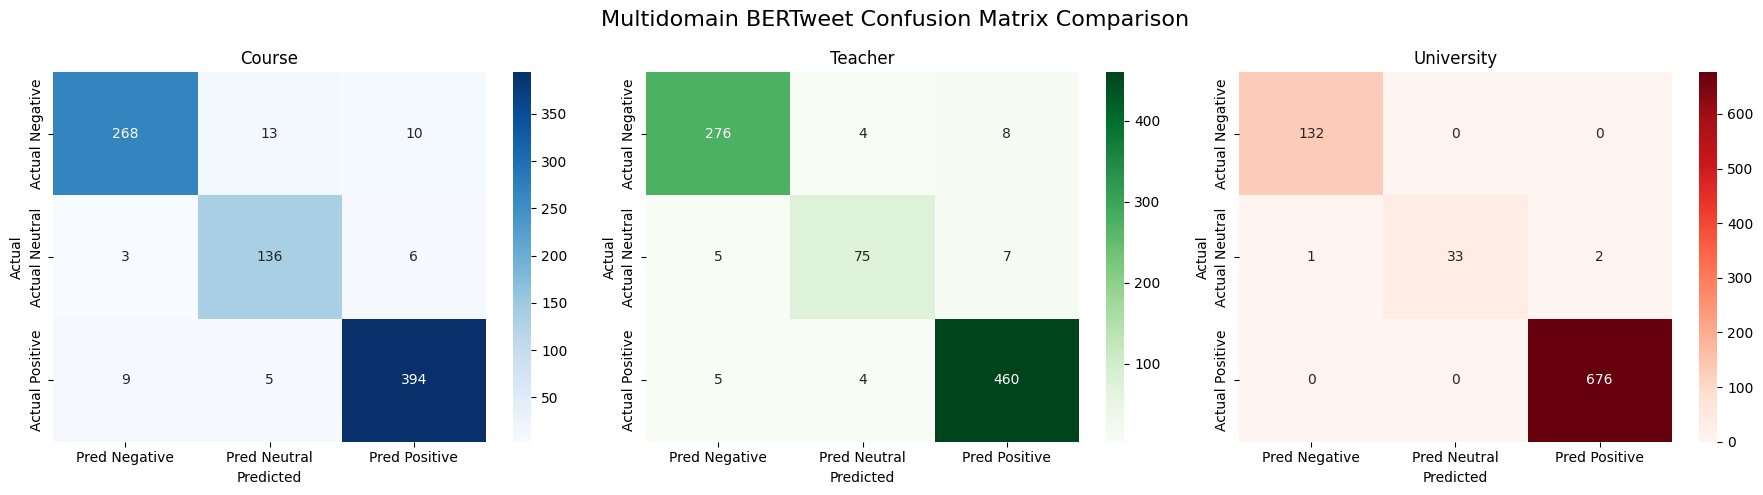

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# =====================================================
# COURSE
# =====================================================

sns.heatmap(
    course_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0]
)

axes[0].set_title("Course")

axes[0].set_xlabel("Predicted")

axes[0].set_ylabel("Actual")

# =====================================================
# TEACHER
# =====================================================

sns.heatmap(
    teacher_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    ax=axes[1]
)

axes[1].set_title("Teacher")

axes[1].set_xlabel("Predicted")

axes[1].set_ylabel("Actual")

# =====================================================
# UNIVERSITY
# =====================================================

sns.heatmap(
    university_cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    ax=axes[2]
)

axes[2].set_title("University")

axes[2].set_xlabel("Predicted")

axes[2].set_ylabel("Actual")

# =====================================================
# FINAL SETTINGS
# =====================================================

plt.suptitle(
    "Multidomain BERTweet Confusion Matrix Comparison",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    f"{BASE_PATH}/results/combined_confusion_matrix_comparison.png"
)

plt.show()

In [55]:
# =====================================================
# LOAD ALL MODEL RESULT FILES
# =====================================================

bertweet_results = pd.read_csv(
    f"{BASE_PATH}/results/final_domain_performance_summary.csv"
)

# -----------------------------------------------------
# LOAD THESE LATER AFTER YOU COMPLETE THEM
# -----------------------------------------------------

# modernbert_results = pd.read_csv(
#     f"{BASE_PATH}/results/modernbert_final_domain_performance_summary.csv"
# )

# llama_results = pd.read_csv(
#     f"{BASE_PATH}/results/llama_final_domain_performance_summary.csv"
# )

# =====================================================
# CREATE COMPARISON TABLE
# =====================================================

final_model_comparison = pd.DataFrame({

    "Model": [
        "BERTweet"
        # "ModernBERT",
        # "LLaMA 3"
    ],

    "Course_Weighted_F1": [

        bertweet_results.loc[
            bertweet_results["Domain"] == "Course",
            "Weighted_F1"
        ].values[0]

        # modernbert_results.loc[
        #     modernbert_results["Domain"] == "Course",
        #     "Weighted_F1"
        # ].values[0],

        # llama_results.loc[
        #     llama_results["Domain"] == "Course",
        #     "Weighted_F1"
        # ].values[0]
    ],

    "Teacher_Weighted_F1": [

        bertweet_results.loc[
            bertweet_results["Domain"] == "Teacher",
            "Weighted_F1"
        ].values[0]

        # modernbert_results.loc[
        #     modernbert_results["Domain"] == "Teacher",
        #     "Weighted_F1"
        # ].values[0],

        # llama_results.loc[
        #     llama_results["Domain"] == "Teacher",
        #     "Weighted_F1"
        # ].values[0]
    ],

    "University_Weighted_F1": [

        bertweet_results.loc[
            bertweet_results["Domain"] == "University",
            "Weighted_F1"
        ].values[0]

        # modernbert_results.loc[
        #     modernbert_results["Domain"] == "University",
        #     "Weighted_F1"
        # ].values[0],

        # llama_results.loc[
        #     llama_results["Domain"] == "University",
        #     "Weighted_F1"
        # ].values[0]
    ],

    "Mean_Weighted_F1": [

        bertweet_results["Weighted_F1"].mean()

        # modernbert_results["Weighted_F1"].mean(),

        # llama_results["Weighted_F1"].mean()
    ]
})

print(final_model_comparison)

final_model_comparison.to_csv(
    f"{BASE_PATH}/results/final_cross_model_comparison.csv",
    index=False
)

      Model  Course_Weighted_F1  Teacher_Weighted_F1  University_Weighted_F1  \
0  BERTweet            0.945623             0.960667                0.996372   

   Mean_Weighted_F1  
0          0.967554  


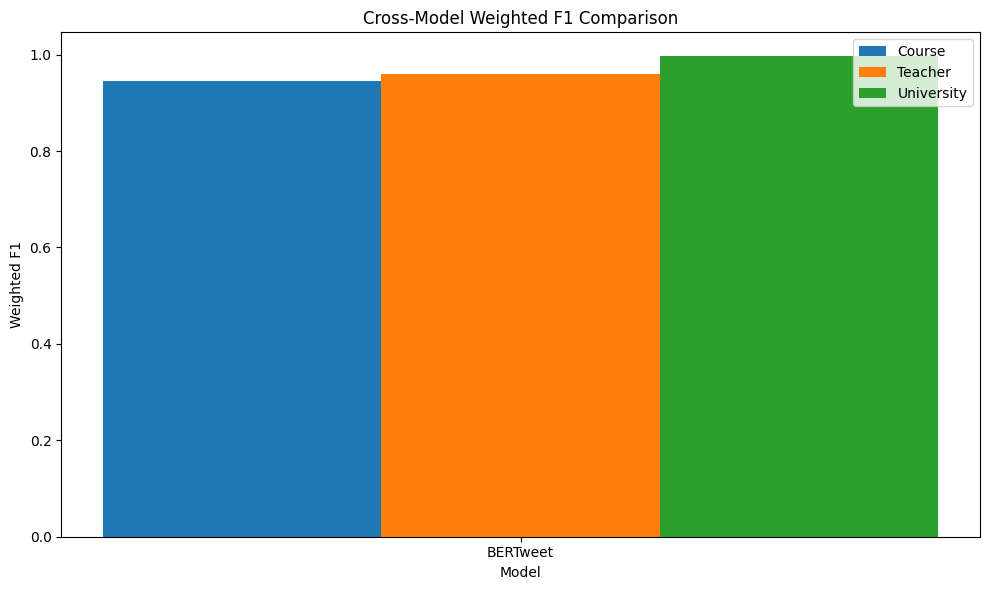

In [56]:
models = final_model_comparison["Model"]

course_scores = final_model_comparison["Course_Weighted_F1"]

teacher_scores = final_model_comparison["Teacher_Weighted_F1"]

university_scores = final_model_comparison["University_Weighted_F1"]

x = np.arange(len(models))

width = 0.25

plt.figure(figsize=(10, 6))

plt.bar(
    x - width,
    course_scores,
    width,
    label="Course"
)

plt.bar(
    x,
    teacher_scores,
    width,
    label="Teacher"
)

plt.bar(
    x + width,
    university_scores,
    width,
    label="University"
)

plt.xticks(
    x,
    models
)

plt.ylabel("Weighted F1")

plt.xlabel("Model")

plt.title("Cross-Model Weighted F1 Comparison")

plt.legend()

plt.tight_layout()

plt.savefig(
    f"{BASE_PATH}/results/cross_model_weighted_f1_comparison.png"
)

plt.show()

In [57]:
summary_report = f"""
=====================================================
MULTIDOMAIN BERTWEET FINAL EXPERIMENT SUMMARY
=====================================================

FINAL BEST CONFIGURATION
-----------------------------------------------------
Model: BERTweet
Learning Rate: 2e-5
Batch Size: 8
Epochs: 7
Weighted Loss: True
Max Length: 128

=====================================================
FINAL DOMAIN RESULTS
=====================================================

{final_domain_results.to_string(index=False)}

=====================================================
OVERALL PERFORMANCE
=====================================================

{overall_results.to_string(index=False)}

=====================================================
MULTIDOMAIN VS CROSS-DOMAIN SUMMARY
=====================================================

{comparison_summary.to_string(index=False)}

=====================================================
HYPERTUNING SUMMARY
=====================================================

{final_results.to_string(index=False)}

=====================================================
KEY FINDINGS
=====================================================

1. Multidomain learning consistently outperformed
   cross-domain learning across all domains.

2. Weighted loss substantially improved neutral
   sentiment classification performance.

3. Batch size 8 achieved the best generalization.

4. Validation loss was not the best stopping
   criterion for multidomain ABSA.

5. University domain was easiest while Course
   domain was the most semantically challenging.

=====================================================
FINAL CONCLUSION
=====================================================

Multidomain BERTweet demonstrated highly robust
aspect-based sentiment classification performance
across educational-review domains, achieving strong
generalization and superior contextual sentiment
understanding compared to cross-domain learning.

=====================================================
"""

print(summary_report)

with open(
    f"{BASE_PATH}/results/final_experiment_summary.txt",
    "w"
) as f:

    f.write(summary_report)


MULTIDOMAIN BERTWEET FINAL EXPERIMENT SUMMARY

FINAL BEST CONFIGURATION
-----------------------------------------------------
Model: BERTweet
Learning Rate: 2e-5
Batch Size: 8
Epochs: 7
Weighted Loss: True
Max Length: 128

FINAL DOMAIN RESULTS

    Domain  Accuracy  Macro_F1  Weighted_F1
    Course  0.945498  0.937243     0.945623
   Teacher  0.960900  0.939534     0.960667
University  0.996445  0.983757     0.996372

OVERALL PERFORMANCE

          Metric    Score
   Mean_Accuracy 0.967615
   Mean_Macro_F1 0.953511
Mean_Weighted_F1 0.967554

MULTIDOMAIN VS CROSS-DOMAIN SUMMARY

    Domain  Total_Samples  Disagreements  Both_Correct  Only_Multidomain_Correct  Only_Crossdomain_Correct  Both_Wrong
    Course            844            173           642                       156                        15          31
   Teacher            844            116           709                       102                         4          29
University            844             67           777   

In [58]:
# =====================================================
# CREATE FINAL EXPORT DIRECTORY
# =====================================================

import os

export_path = f"{BASE_PATH}/results/dissertation_tables"

os.makedirs(
    export_path,
    exist_ok=True
)

# =====================================================
# EXPORT FINAL TABLES
# =====================================================

final_domain_results.to_csv(
    f"{export_path}/table_domain_performance.csv",
    index=False
)

overall_results.to_csv(
    f"{export_path}/table_overall_performance.csv",
    index=False
)

comparison_summary.to_csv(
    f"{export_path}/table_multidomain_vs_crossdomain.csv",
    index=False
)

final_results.to_csv(
    f"{export_path}/table_hypertuning_results.csv",
    index=False
)

final_model_comparison.to_csv(
    f"{export_path}/table_cross_model_comparison.csv",
    index=False
)

print("All dissertation tables exported successfully.")

print("\nExport Location:")
print(export_path)

All dissertation tables exported successfully.

Export Location:
/content/drive/MyDrive/ABSA_BERT_MULTIDOMAIN/results/dissertation_tables


In [59]:
from IPython.display import Markdown, display

markdown_text = r"""
# Multidomain Aspect-Based Sentiment Analysis using BERTweet

---

# Project Overview

This project implements a complete research-grade multidomain Aspect-Based Sentiment Analysis (ABSA) pipeline using the BERTweet transformer model.

The objective of the project was to investigate whether multidomain learning improves sentiment classification performance compared to cross-domain transfer learning across educational-review datasets.

The experiments were conducted on three educational-review domains:

- Course Reviews
- Teacher Reviews
- University Reviews

The project includes:

- Multidomain training
- Hyperparameter tuning
- Weighted-loss optimization
- Domain-wise evaluation
- Row-level prediction comparison
- Cross-domain comparison
- Disagreement analysis
- Neutral sentiment analysis
- Research-grade visualization pipeline
- Dissertation-ready export pipeline

---

# Final Best Configuration

| Parameter | Value |
|---|---|
| Model | BERTweet |
| Learning Rate | 2e-5 |
| Batch Size | 8 |
| Epochs | 7 |
| Weighted Loss | True |
| Max Length | 128 |

---

# Final Domain Results

| Domain | Accuracy | Macro F1 | Weighted F1 |
|---|---|---|---|
| Course | 0.945498 | 0.937243 | 0.945623 |
| Teacher | 0.960900 | 0.939534 | 0.960667 |
| University | 0.996445 | 0.983757 | 0.996372 |

---

# Overall Aggregate Performance

| Metric | Score |
|---|---|
| Mean Accuracy | 0.967615 |
| Mean Macro F1 | 0.953511 |
| Mean Weighted F1 | 0.967554 |

---

# Multidomain vs Cross-Domain Comparison

| Domain | Multidomain Better | Cross-domain Better |
|---|---|---|
| Course | 156 | 15 |
| Teacher | 102 | 4 |
| University | 64 | 0 |

Overall:

| Outcome | Count |
|---|---|
| Multidomain uniquely correct | 322 |
| Cross-domain uniquely correct | 19 |

---

# Key Findings

## 1. Multidomain Learning Outperformed Cross-domain Learning

Multidomain BERTweet consistently achieved superior performance across all educational-review domains.

---

## 2. Weighted Loss Improved Neutral Sentiment Performance

Weighted loss significantly improved minority-class learning and neutral sentiment classification.

---

## 3. Smaller Batch Sizes Improved Generalization

Batch size 8 consistently produced the strongest results across domains.

---

## 4. Validation Loss Was Not the Best Stopping Criterion

Although validation loss increased during later epochs, classification metrics continued improving.

This indicates that validation loss alone was not an ideal stopping criterion for multidomain ABSA.

---

## 5. Domain Difficulty Varied Significantly

| Domain | Difficulty |
|---|---|
| Course | Hardest |
| Teacher | Moderate |
| University | Easiest |

---

# Final Conclusion

Multidomain BERTweet demonstrated highly robust and generalizable aspect-based sentiment classification performance across educational-review domains.

The multidomain learning strategy substantially outperformed cross-domain transfer learning in both quantitative performance and qualitative contextual understanding.

"""

display(Markdown(markdown_text))


# Multidomain Aspect-Based Sentiment Analysis using BERTweet

---

# Project Overview

This project implements a complete research-grade multidomain Aspect-Based Sentiment Analysis (ABSA) pipeline using the BERTweet transformer model.

The objective of the project was to investigate whether multidomain learning improves sentiment classification performance compared to cross-domain transfer learning across educational-review datasets.

The experiments were conducted on three educational-review domains:

- Course Reviews
- Teacher Reviews
- University Reviews

The project includes:

- Multidomain training
- Hyperparameter tuning
- Weighted-loss optimization
- Domain-wise evaluation
- Row-level prediction comparison
- Cross-domain comparison
- Disagreement analysis
- Neutral sentiment analysis
- Research-grade visualization pipeline
- Dissertation-ready export pipeline

---

# Final Best Configuration

| Parameter | Value |
|---|---|
| Model | BERTweet |
| Learning Rate | 2e-5 |
| Batch Size | 8 |
| Epochs | 7 |
| Weighted Loss | True |
| Max Length | 128 |

---

# Final Domain Results

| Domain | Accuracy | Macro F1 | Weighted F1 |
|---|---|---|---|
| Course | 0.945498 | 0.937243 | 0.945623 |
| Teacher | 0.960900 | 0.939534 | 0.960667 |
| University | 0.996445 | 0.983757 | 0.996372 |

---

# Overall Aggregate Performance

| Metric | Score |
|---|---|
| Mean Accuracy | 0.967615 |
| Mean Macro F1 | 0.953511 |
| Mean Weighted F1 | 0.967554 |

---

# Multidomain vs Cross-Domain Comparison

| Domain | Multidomain Better | Cross-domain Better |
|---|---|---|
| Course | 156 | 15 |
| Teacher | 102 | 4 |
| University | 64 | 0 |

Overall:

| Outcome | Count |
|---|---|
| Multidomain uniquely correct | 322 |
| Cross-domain uniquely correct | 19 |

---

# Key Findings

## 1. Multidomain Learning Outperformed Cross-domain Learning

Multidomain BERTweet consistently achieved superior performance across all educational-review domains.

---

## 2. Weighted Loss Improved Neutral Sentiment Performance

Weighted loss significantly improved minority-class learning and neutral sentiment classification.

---

## 3. Smaller Batch Sizes Improved Generalization

Batch size 8 consistently produced the strongest results across domains.

---

## 4. Validation Loss Was Not the Best Stopping Criterion

Although validation loss increased during later epochs, classification metrics continued improving.

This indicates that validation loss alone was not an ideal stopping criterion for multidomain ABSA.

---

## 5. Domain Difficulty Varied Significantly

| Domain | Difficulty |
|---|---|
| Course | Hardest |
| Teacher | Moderate |
| University | Easiest |

---

# Final Conclusion

Multidomain BERTweet demonstrated highly robust and generalizable aspect-based sentiment classification performance across educational-review domains.

The multidomain learning strategy substantially outperformed cross-domain transfer learning in both quantitative performance and qualitative contextual understanding.

